# Atividade de vendas no Brasil

In [129]:
# Impotando as bibiliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
# Lendo o dataset
df_vendas_br = pd.read_csv('../../data/vendas_brasil_1.csv')

In [131]:
print(df_vendas_br.head())

   data_venda  mes          cidade canal_venda    categoria      produto  \
0  2022-04-13    4  Rio de Janeiro  App Mobile  Eletrônicos     Notebook   
1  2023-03-12    3          Manaus    Site Web    Vestuário     Camiseta   
2  2022-09-28    9         Goiânia  App Mobile    Vestuário        Tênis   
3  2022-04-17    4       Fortaleza    Site Web    Vestuário  Calça Jeans   
4  2022-03-13    3  Belo Horizonte  App Mobile     Esportes    Bicicleta   

       vendedor fidelidade_cliente  preco_unitario  custo_unitario  ...  \
0   Bruno Souza           Diamante          739.39          561.75  ...   
1   Elisa Costa             Bronze          187.48          135.15  ...   
2   João Vieira             Bronze           76.11           61.40  ...   
3  Carla Mendes             Bronze          145.86           88.53  ...   
4   João Vieira             Bronze          133.92          107.25  ...   

   quantidade  desconto_pct  receita_total  frete  avaliacao_cliente  \
0          10       

## Entregável 1 - NumPy

 - Cálculos numéricos, operações vetorizadas, máscaras booleanas e agregações.

In [132]:
# Criando arrays
# A partir do dataset, crie arrays NumPy para algumas colunas numéricas, como preço unitário, custo unitário, quantidade, desconto, receita total e frete.
preco_unitario_np = np.array(df_vendas_br['preco_unitario'])
custo_unitario_np = np.array(df_vendas_br['custo_unitario'])
quantidade_np = np.array(df_vendas_br['quantidade'])
desconto_np = np.array(df_vendas_br['desconto_pct'])
receita_total_np = np.array(df_vendas_br['receita_total'])
frete_np = np.array(df_vendas_br['frete'])

In [133]:
# Cálculos com operações vetorizadas
## 1. valor bruto da venda
valor_bruto_venda = preco_unitario_np * quantidade_np

## 2. valor do desconto
valor_desconto = valor_bruto_venda * (desconto_np/100)

## 3. custo total
custo_total = custo_unitario_np * quantidade_np

## 4. lucro estimado
lucro_estimado = valor_bruto_venda - valor_desconto - custo_total

In [134]:
# Máscaras booleanas
## 1. vendas com receita acima da média
media_receita = np.mean(receita_total_np)
vendas_acima_media = receita_total_np > media_receita
print("Quantidade de vendas com receita acima da média:", vendas_acima_media.sum())
print("Proporção de vendas com receita acima da média:", f"{(vendas_acima_media.sum() / len(receita_total_np))*100:.3f}","%")

## 2. vendas com prejuízo
prejuizo = lucro_estimado < 0
print("Quantidade de vendas com prejuízo:", prejuizo.sum())
print("Proporção de vendas com prejuízo:", f"{(prejuizo.sum() / len(lucro_estimado))*100:.3f}","%")

## 3. vendas com desconto alto
desconto_alto = desconto_np > 25 # Considerando descontos altos acima de 25%
print("Quantidade de vendas com desconto alto:", desconto_alto.sum())
print("Proporção de vendas com desconto alto:", f"{(desconto_alto.sum() / len(desconto_np))*100:.3f}","%")

Quantidade de vendas com receita acima da média: 9236
Proporção de vendas com receita acima da média: 24.553 %
Quantidade de vendas com prejuízo: 2857
Proporção de vendas com prejuízo: 7.595 %
Quantidade de vendas com desconto alto: 2304
Proporção de vendas com desconto alto: 6.125 %


In [135]:
# Agregações
## 1. receita média
receita_media = np.mean(receita_total_np)
print("Receita média:", f"{receita_media:.3f}")

## 2. maior receita
maior_receita = np.max(receita_total_np)
print("Maior receita:", f"{maior_receita:.3f}")

## 3. menor receita
menor_receita = np.min(receita_total_np)
print("Menor receita:", f"{menor_receita:.3f}")

## 4. lucro médio
lucro_medio = np.mean(lucro_estimado)
print("Lucro estimado médio:", f"{lucro_medio:.3f}")

## 5. quantidade de vendas com prejuízo
quantidade_vendas_prejuizo = np.sum(prejuizo)
print("Vendas com prejuízo:", quantidade_vendas_prejuizo)

Receita média: 1891.688
Maior receita: 58430.280
Menor receita: 3.700
Lucro estimado médio: 342.032
Vendas com prejuízo: 2857


uma breve conclusão sobre o comportamento geral das vendas

## Entregável 2 - Pandas

 - Ler, explorar, limpar, transformar e agrupar os dados.

In [136]:
df_vendas_br.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


In [137]:
df_vendas_br.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  object 
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  object 
 3   canal_venda         37567 non-null  object 
 4   categoria           37617 non-null  object 
 5   produto             37617 non-null  object 
 6   vendedor            37577 non-null  object 
 7   fidelidade_cliente  37617 non-null  object 
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  praz

In [138]:
df_vendas_br.describe()

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000


In [139]:
df_vendas_br.shape

(37617, 21)

In [140]:
# Identificar dados nulos ou ausentes
df_vendas_br.isna().sum()

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

1. Quantas linhas e colunas existem?
Linhas: 37617
Colunas: 21

2. Existem dados faltantes?
Sim, nas colunas: canal_venda(50 dados faltantes), vendedor(40 dados faltantes), frete(1879 dados faltantes), avaliacao_cliente(2955 dados faltantes) e prazo_entrega_dias(1504 dados faltantes).

3. Quais colunas parecem numéricas?
mes, preco_unitario, custto_unitario, margem_pct, quantidade, desconto_pct, receita_total, frete, avaliacao_cliente, prazo_entrega_dias

4. Quais colunas parecem categóricas?
data_venda, cidade, canal_venda, categoria, produto, vendedor, fidelidade_cliente, devolucao, entrega_no_prazo, alta_temporada, flag_outlier_preco

In [141]:
# Limpeza e tratamento de dados
## 1. converta a coluna de data para o tipo datetime
df_vendas_br['data_venda'] = pd.to_datetime(df_vendas_br['data_venda'], format='mixed')
data_venda = df_vendas_br['data_venda']

print(data_venda.dtype)

datetime64[ns]


In [142]:
## 2. padronize pelo menos uma coluna categórica que tenha valores escritos de formas diferentes
print(df_vendas_br['cidade'].unique())
df_vendas_br['cidade'] = df_vendas_br['cidade'].str.strip()
df_vendas_br['cidade'] = df_vendas_br['cidade'].replace({
    'salvador': 'Salvador',
    'Rio de janeiro': 'Rio de Janeiro',
    'SP': 'São Paulo',
    'S. Paulo': 'São Paulo',
    'São paulo': 'São Paulo',
    'Sao Paulo': 'São Paulo',
    'BH': 'Belo Horizonte',
    'Slavador': 'Salvador',
    'Belo horizonte': 'Belo Horizonte',
    'Rio': 'Rio de Janeiro',
    'Rio De Janeiro': 'Rio de Janeiro',
    'Curtiba': 'Curitiba',
    'curitiba': 'Curitiba',
    'B. horizonte': 'Belo Horizonte',
    'B. Horizonte': 'Belo Horizonte',
    'RJ': 'Rio de Janeiro'
    })
# Conferindo as alterações
print(df_vendas_br['cidade'].unique())

['Rio de Janeiro' 'Manaus' 'Goiânia' 'Fortaleza' 'Belo Horizonte' 'Recife'
 'São Paulo' 'Porto Alegre' 'Salvador' 'Curitiba' 'salvador'
 'Belo Horizonte ' 'Rio de janeiro' 'Curtiba' 'Curitiba ' 'SP'
 ' Fortaleza' 'curitiba' 'RJ' 'S. Paulo' ' Salvador' 'Manaus ' 'São paulo'
 'Fortaleza ' 'Sao Paulo' 'BH' 'Rio de Janeiro ' ' Belo Horizonte'
 ' Recife' 'Slavador' 'Belo horizonte' 'Rio' ' Curitiba' ' Manaus'
 ' Goiânia' 'Recife ' 'B. Horizonte' 'Porto Alegre ' 'Rio De Janeiro'
 'São Paulo ' 'Goiânia ' ' Porto Alegre' 'Salvador ' ' Rio de Janeiro'
 ' São Paulo']
['Rio de Janeiro' 'Manaus' 'Goiânia' 'Fortaleza' 'Belo Horizonte' 'Recife'
 'São Paulo' 'Porto Alegre' 'Salvador' 'Curitiba']


In [143]:
df_vendas_br['canal_venda'] = df_vendas_br['canal_venda'].str.strip()
df_vendas_br['canal_venda'] = df_vendas_br['canal_venda'].str.lower()
print(df_vendas_br['canal_venda'].unique())
df_vendas_br['canal_venda'] = df_vendas_br['canal_venda'].replace({
    'app mobile': 'App Mobile',
    'loja fisica': 'Loja Física',
    'site web': 'Site Web',
    'loja física': 'Loja Física',
    'marketplace': 'Marketplace',
    'televendas': 'Televendas',
    'siteweb': 'Site Web'
    })
# Conferindo as alterações
print(df_vendas_br['canal_venda'].unique())

['app mobile' 'site web' 'loja física' 'marketplace' 'televendas'
 'siteweb' nan 'loja fisica']
['App Mobile' 'Site Web' 'Loja Física' 'Marketplace' 'Televendas' nan]


In [144]:
df_vendas_br['fidelidade_cliente'] = df_vendas_br['fidelidade_cliente'].str.strip()
df_vendas_br['fidelidade_cliente'] = df_vendas_br['fidelidade_cliente'].str.lower()
print(df_vendas_br['fidelidade_cliente'].unique())
df_vendas_br['fidelidade_cliente'] = df_vendas_br['fidelidade_cliente'].replace({
    'diamante': 'Diamante',
    'ouro': 'Ouro',
    'bronze': 'Bronze',
    'prata': 'Prata'
})
# Conferindo as alterações
print(df_vendas_br['fidelidade_cliente'].unique())

['diamante' 'bronze' 'prata' 'ouro']
['Diamante' 'Bronze' 'Prata' 'Ouro']


In [145]:
print(df_vendas_br['produto'].unique())
df_vendas_br['produto'] = df_vendas_br['produto'].str.strip()

['Notebook' 'Camiseta' 'Tênis' 'Calça Jeans' 'Bicicleta'
 'Machine Learning' 'Python para Dados' 'Mel Orgânico' 'Whey Protein'
 'Bermuda' 'Jaqueta' 'Raquete' 'Smartphone' 'Álgebra Linear' 'Smartwatch'
 ' Garrafa Térmica' ' Jaqueta' 'Luva de Box' 'Cálculo Vol.1'
 'Barra de Cereal' 'Estatística Aplicada' 'Tablet' 'Garrafa Térmica'
 'Tapete de Yoga' 'Fone Bluetooth' 'Azeite' 'Granola' 'Barra de Cereal '
 ' Fone Bluetooth' ' Tapete de Yoga' ' Notebook' ' Bicicleta' 'Raquete '
 'Camiseta ' 'Bermuda ' 'Fone Bluetooth ' ' Azeite' 'Cálculo Vol.1 '
 'Smartphone ' ' Cálculo Vol.1' 'Notebook ' 'Python para Dados '
 'Calça Jeans ' 'Granola ' ' Smartphone' ' Calça Jeans' ' Tablet'
 'Álgebra Linear ' 'Estatística Aplicada ' ' Barra de Cereal'
 ' Python para Dados' 'Machine Learning ' ' Granola' ' Álgebra Linear'
 ' Whey Protein' 'Garrafa Térmica ' 'Tapete de Yoga ' 'Tablet ' 'Tênis '
 ' Raquete' 'Mel Orgânico ' 'Azeite ' ' Camiseta' ' Mel Orgânico'
 'Jaqueta ' 'Whey Protein ' ' Machine Learning']


In [146]:
## 3. trate alguns dados faltantes de forma adequada
df_vendas_br.groupby('produto')['prazo_entrega_dias'].agg(['median']).sort_values('median')
df_vendas_br['prazo_entrega_dias'] = df_vendas_br.groupby('produto')['prazo_entrega_dias'].transform(lambda x: x.fillna(x.median()))
# Caso os valores de prazo de entrega estejam faltando, preenchi com a mediana do prazo de entrega para cada produto. A mediana é uma medida não afetada por valores extremos, tornando-a uma escolha adequada para preencher dados faltantes em casos com distribuições assimétricas.

In [147]:
# Criação de novas colunas
from numpy import int64
## 1. ano da venda
df_vendas_br['ano_venda'] = df_vendas_br['data_venda'].dt.year.astype(int64)
## 2. mês da venda
df_vendas_br['mes_venda'] = df_vendas_br['data_venda'].dt.month.astype(int64)
## 3. lucro total
df_vendas_br['lucro_total'] = df_vendas_br.apply(lambda row: row['preco_unitario'] * row['quantidade'] * (1 - row['desconto_pct'] / 100) - row['custo_unitario'] * row['quantidade'], axis=1) 


In [148]:
# Filtros
## 1. Quais vendas tiveram receita acima de determinado valor?
profit = df_vendas_br[df_vendas_br['lucro_total'] > 1000]
## 2. Quais vendas tiveram devolução?
devolucao = df_vendas_br[df_vendas_br['devolucao'] == True]
## 3. Quais vendas pertencem a uma categoria específica?
categoria_especifica = df_vendas_br[df_vendas_br['categoria'] == 'Eletrônicos']

print("Vendas com lucro acima de 1000:", profit.shape[0])
print("Vendas com devolução:", devolucao.shape[0])
print("Vendas na categoria Eletrônicos:", categoria_especifica.shape[0])

Vendas com lucro acima de 1000: 3386
Vendas com devolução: 3532
Vendas na categoria Eletrônicos: 7515


3386 tiveram lucro acima de 1000 reais, 3532 vendas foram devolvidas e 7515 vendas foram de eletrônicos.

In [149]:
# Agrupamentos com groupby
#pelo menos 3 
## 1. Qual categoria teve maior receita total? Eletrônicos
print(df_vendas_br.groupby('categoria')['receita_total'].sum().sort_values(ascending=False).head(1))
## 2. Qual canal de venda teve maior quantidade de vendas? Site Web
print(df_vendas_br.groupby('canal_venda')['quantidade'].sum().sort_values(ascending=False).head(1))
## 3. Qual cidade teve maior receita? Recife
print(df_vendas_br.groupby('cidade')['receita_total'].sum().sort_values(ascending=False).head(1))
## 4. Qual categoria teve maior lucro? Eletrônicos
print(df_vendas_br.groupby('categoria')['lucro_total'].sum().sort_values(ascending=False).head(1))

categoria
Eletrônicos    45017479.88
Name: receita_total, dtype: float64
canal_venda
Site Web    85091
Name: quantidade, dtype: int64
cidade
Recife    7662241.79
Name: receita_total, dtype: float64
categoria
Eletrônicos    8.141113e+06
Name: lucro_total, dtype: float64


In [150]:
# F. Merge
from pandas import DataFrame
from pandas import merge
df_regioes = pd.DataFrame({
    'cidade': ['Rio de Janeiro', 'Manaus', 'São Paulo', 'Belo Horizonte', 'Porto Alegre', 'Curitiba', 'Recife', 'Salvador', 'Fortaleza', 'Goiânia'],
    'regiao': ['Sudeste', 'Norte', 'Sudeste', 'Sudeste', 'Sul', 'Sul', 'Nordeste', 'Nordeste', 'Nordeste', 'Centro-Oeste']
})

df_vendas_br = df_vendas_br.merge(df_regioes, on='cidade', how='left')
receita_por_regiao = df_vendas_br.groupby('regiao')['receita_total'].sum().reset_index()

In [151]:
receita_por_regiao

,regiao,receita_total
0,Centro-Oeste,7178113.69
1,Nordeste,21822979.62
2,Norte,7459161.23
3,Sudeste,20657776.22
4,Sul,14041603.24


 breve conclusão sobre os principais resultados encontrados.

## Entregável 3 - Seaborn

 - Neste entregável, o foco é criar visualizações com Seaborn e interpretar os gráficos.
Você pode usar Pandas para preparar os dados antes de gerar os gráficos. Tente não entregar apenas o
gráfico bruto padrão do Seaborn. Procure melhorar a apresentação visual usando recursos como 
sns.despine() , 
linewidth , 
sample , 
resample , ajuste de tamanho da figura, rotação de
rótulos, títulos claros e outras personalizações. Se preferir usar Matplotlib junto com Seaborn para
melhorar os gráficos, também pode usar.

Cuidados com os gráficos
Os gráficos devem ter título, nomes nos eixos, tamanho adequado e rotação dos rótulos quando
necessário.
Também é esperado que você use pelo menos alguns recursos de acabamento visual, como 
sns.despine() , 
linewidth , 
sample , 
resample ou ajustes com Matplotlib.
Depois de cada gráfico, escreva uma interpretação curta em Markdown explicando o que aquele gráfico
mostra.

C:\Users\marce\AppData\Local\Temp\ipykernel_16956\1872960504.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot.index, y=plot.values, palette='viridis', edgecolor='black')


Text(0, 0.5, 'Receita Total')

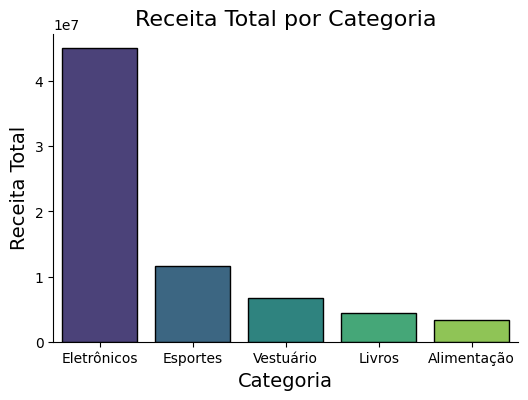

In [205]:
# Visualizações
## Gráfico de barras da receita por categoria
plt.figure(figsize=(6, 4))
plot = df_vendas_br.groupby('categoria')['receita_total'].sum().sort_values(ascending=False)
sns.barplot(x=plot.index, y=plot.values, palette='viridis', edgecolor='black')
sns.despine()
plt.title('Receita Total por Categoria', fontsize=16)
plt.xlabel('Categoria', fontsize=14)
plt.ylabel('Receita Total', fontsize=14)

Text(0, 0.5, 'Receita Total')

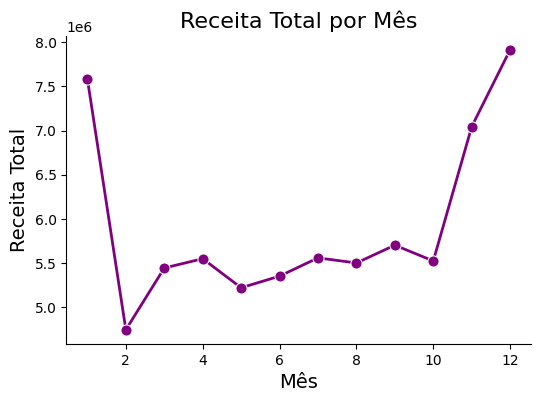

In [206]:
## Gráfico de linhas da receita por mês
plt.figure(figsize=(6, 4))
sns.lineplot(data=df_vendas_br.groupby('mes_venda')['receita_total'].sum().reset_index(), x='mes_venda', y='receita_total', marker='o', color='purple', linestyle='-', linewidth=2, markersize=8)
sns.despine()
plt.title('Receita Total por Mês', fontsize=16)
plt.xlabel('Mês', fontsize=14)
plt.ylabel('Receita Total', fontsize=14)

Text(0, 0.5, 'Receita Total')

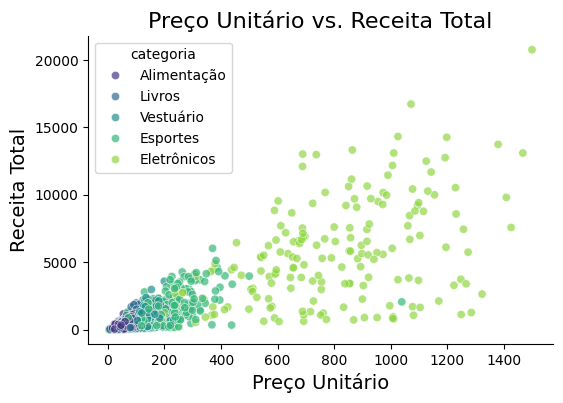

In [208]:
## Gráfico de disperão de preço unitário e receita total
plt.figure(figsize=(6, 4))
df_amostra = df_vendas_br.sample(n=1000, random_state=42)  # Amostra de 1000 registros para melhor visualização
sns.scatterplot(data=df_amostra, x='preco_unitario', y='receita_total', hue='categoria', palette='viridis', alpha=0.7, linewidth=0.5)
sns.despine()
plt.title('Preço Unitário vs. Receita Total', fontsize=16)
plt.xlabel('Preço Unitário', fontsize=14)
plt.ylabel('Receita Total', fontsize=14)

A conclusão que chegamos a partir deste gráfico de dispersão é que 

Text(0.5, 1.0, 'Mapa de Calor da Correlação entre Variáveis Numéricas')

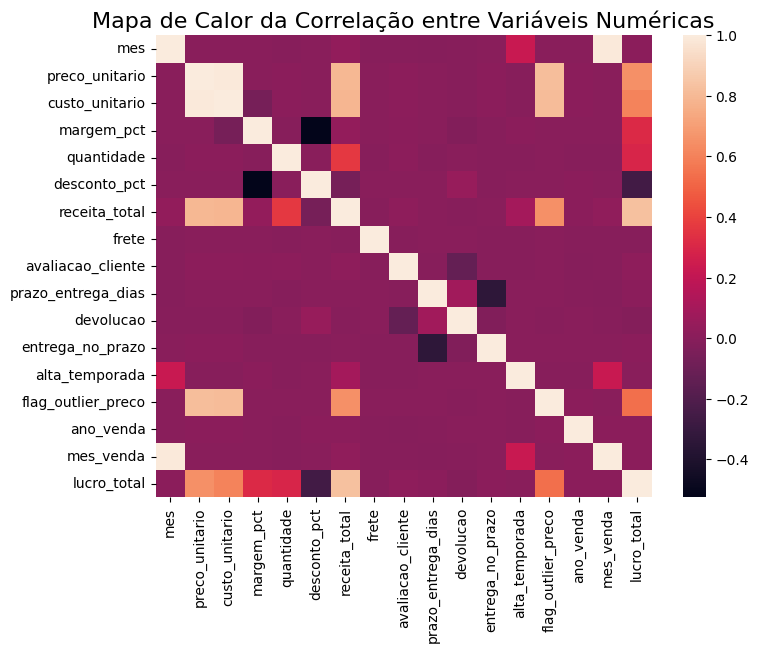

In [209]:
## Mapa de calor da correlação entre variáveis numéricas
plt.figure(figsize=(8, 6))
sns.heatmap(df_vendas_br.corr(numeric_only=True))
plt.title('Mapa de Calor da Correlação entre Variáveis Numéricas', fontsize=16)